In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_parquet("./output/natality_2021_numeric.parquet")

df.head()

,birth_year,birth_month,time_of_birth,birth_day_of_week,birth_place,facility_reporting_flag,facility_recode,mothers_age_imputed,reported_mothers_age_used,mothers_single_year_age,...,cleft_palate_reporting_flag,down_syndrome_reporting_flag,suspected_chromosomal_disorder_reporting_flag,hypospadias_reporting_flag,no_congenital_abnormalities_reported,infant_transferred,infant_living_at_time_of_report,infant_breastfed_at_discharge,infant_breastfed_at_discharge_reporting_flag,2021
0,2021,1,636,7,1,1,1,NaN,NaN,22,...,1,1,1,1,1,0.0,1.0,1.0,1,2021
1,2021,1,259,7,1,1,1,NaN,NaN,31,...,1,1,1,1,1,0.0,1.0,1.0,1,2021
2,2021,1,223,1,1,1,1,NaN,NaN,29,...,1,1,1,1,1,0.0,1.0,1.0,1,2021
3,2021,1,241,1,1,1,1,NaN,NaN,39,...,1,1,1,1,1,0.0,1.0,1.0,1,2021
4,2021,1,503,1,1,1,1,NaN,NaN,20,...,1,1,1,1,1,0.0,1.0,0.0,1,2021


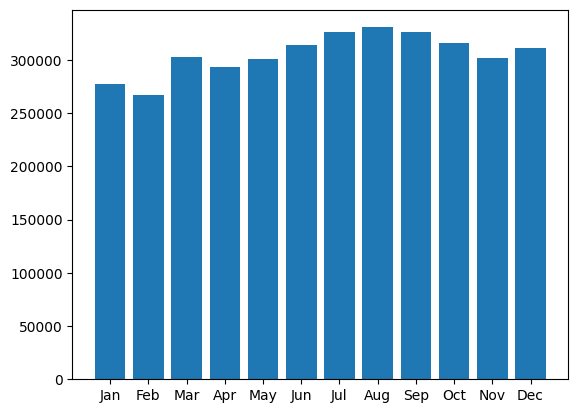

In [3]:
births_per_month_histogram = plt.bar(
    x=[
        "Jan",
        "Feb",
        "Mar",
        "Apr",
        "May",
        "Jun",
        "Jul",
        "Aug",
        "Sep",
        "Oct",
        "Nov",
        "Dec",
    ],
    height=df["birth_month"].value_counts(sort=False),
)

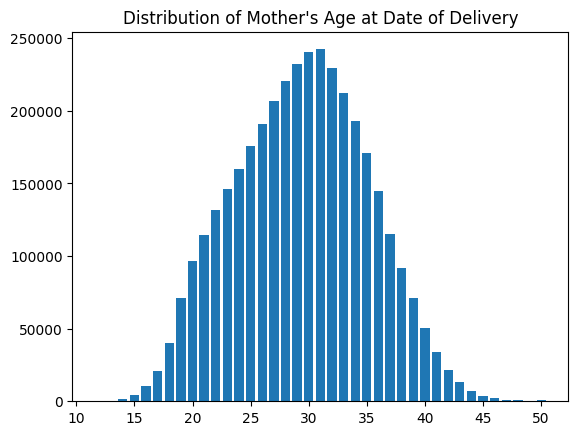

In [4]:
mothers_single_year_age_value_counts = df["mothers_single_year_age"].value_counts(
    sort=False
)

mothers_single_year_age_value_counts = mothers_single_year_age_value_counts.sort_index()

_, mothers_age_histogram_ax = plt.subplots()

mothers_age_histogram_ax.set_title("Distribution of Mother's Age at Date of Delivery")
mothers_age_histogram_ax.bar(
    mothers_single_year_age_value_counts.index,
    mothers_single_year_age_value_counts.values,
)

plt.show()

In [5]:
delivery_method_value_counts = df["delivery_method_recode_7"].value_counts()

delivery_method_value_counts_df = pd.DataFrame(delivery_method_value_counts)

delivery_method_value_counts_df = delivery_method_value_counts_df.merge(
    pd.DataFrame(
        {
            "label": [
                "Vaginal Birth",
                "Vaginal Birth After C-Section",
                "Primary C-Section",
                "Repeat C-Section",
                "Vaginal Birth, Previous C-Section Unknown",
                "C-Section, Previous C-Section Unknown",
                "Unknown",
            ],
        },
        index=[1, 2, 3, 4, 5, 6, 9],
    ),
    left_index=True,
    right_index=True,
)

C:\Users\Alexa\AppData\Local\Temp\ipykernel_3044\1308769662.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  delivery_method_value_counts_df_ax.set_yticklabels(np.arange(0, 3000000, 500000))


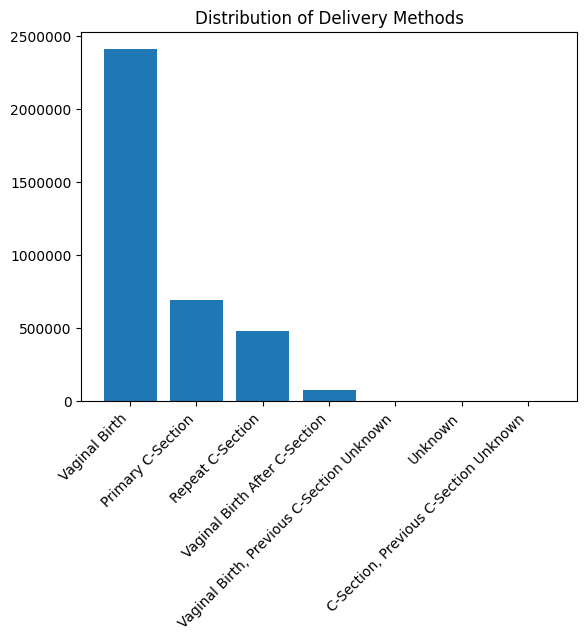

In [6]:
_, delivery_method_value_counts_df_ax = plt.subplots()

delivery_method_value_counts_df_ax.set_title("Distribution of Delivery Methods")
delivery_method_value_counts_df_ax.set_yticklabels(np.arange(0, 3000000, 500000))
delivery_method_value_counts_df_ax.bar(
    delivery_method_value_counts_df["label"],
    delivery_method_value_counts_df["count"],
)
labels = delivery_method_value_counts_df_ax.get_xticklabels()
plt.setp(labels, rotation=45, horizontalalignment="right")

plt.show()

In [9]:
vbac_df = df.loc[df["delivery_method_recode_7"] == 2]

vbac_df.head()

,birth_year,birth_month,time_of_birth,birth_day_of_week,birth_place,facility_reporting_flag,facility_recode,mothers_age_imputed,reported_mothers_age_used,mothers_single_year_age,...,cleft_palate_reporting_flag,down_syndrome_reporting_flag,suspected_chromosomal_disorder_reporting_flag,hypospadias_reporting_flag,no_congenital_abnormalities_reported,infant_transferred,infant_living_at_time_of_report,infant_breastfed_at_discharge,infant_breastfed_at_discharge_reporting_flag,2021
54,2021,1,852,4,1,1,1,NaN,NaN,25,...,1,1,1,1,1,0.0,1.0,1.0,1,2021
60,2021,1,55,4,1,1,1,NaN,NaN,30,...,1,1,1,1,1,0.0,1.0,1.0,1,2021
62,2021,1,1742,7,1,1,1,NaN,NaN,33,...,1,1,1,1,1,0.0,1.0,1.0,1,2021
118,2021,1,1353,2,1,1,1,NaN,NaN,25,...,1,1,1,1,1,0.0,1.0,1.0,1,2021
235,2021,1,2347,4,1,1,1,NaN,NaN,28,...,1,1,1,1,1,0.0,1.0,1.0,1,2021


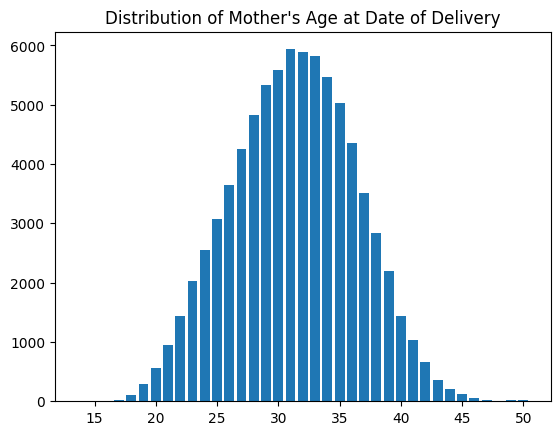

In [11]:
vbac_mothers_age_value_counts = vbac_df["mothers_single_year_age"].value_counts()

vbac_mothers_age_value_counts = vbac_mothers_age_value_counts.sort_index()

_, vbac_mothers_age_value_counts_ax = plt.subplots()

vbac_mothers_age_value_counts_ax.set_title(
    "Distribution of Mother's Age at Date of Delivery"
)
vbac_mothers_age_value_counts_ax.bar(
    vbac_mothers_age_value_counts.index,
    vbac_mothers_age_value_counts.values,
)

plt.show()

In [17]:
vbac_previous_c_section_number_value_counts = vbac_df[
    "number_of_previous_cesarean"
].value_counts()

vbac_previous_c_section_number_value_counts = (
    vbac_previous_c_section_number_value_counts.sort_index()
)
vbac_previous_c_section_number_value_counts = (
    vbac_previous_c_section_number_value_counts.drop(index=99)
)

vbac_previous_c_section_number_value_counts

number_of_previous_cesarean
1    72197
2     6246
3      791
4      168
5       55
6       13
7        3
8        2
9        2
Name: count, dtype: int64

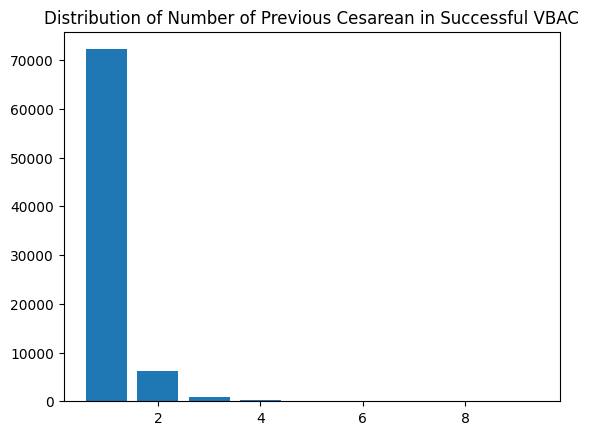

In [20]:
_, vbac_previous_c_section_number_value_counts_ax = plt.subplots()

vbac_previous_c_section_number_value_counts_ax.set_title(
    "Distribution of Number of Previous Cesarean in Successful VBAC"
)
vbac_previous_c_section_number_value_counts_ax.bar(
    vbac_previous_c_section_number_value_counts.index,
    vbac_previous_c_section_number_value_counts.values,
)

plt.show()